# Churn Prediction | Explicabilidade (SHAP) + Tuning de Hiperparâmetros (Optuna)
**Objetivo:** Entender *por que* o modelo decide e encontrar os melhores hiperparâmetros.  
**SHAP:** SHapley Additive exPlanations: atribui a cada feature sua contribuição individual para cada predição.  
**Optuna:** Framework de otimização Bayesiana que realiza busca inteligente no espaço de hiperparâmetros.

## 0. Imports e configuração

In [1]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import joblib
import shap
import optuna
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Carregamento dos datasets
Todos os datasets gerados anteriormente preprocesso e best_model.  
Nenhum reprocessamento é feito aqui.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
preprocessor = joblib.load('../models/preprocessor.pkl')
best_model   = joblib.load('../models/best_model.pkl')

# transform apenas - fit foi feito exclusivamente no treino.
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Datasets carregados.")

Datasets carregados.


## 2. Explicabilidade com SHAP
O SHAP atribui a cada feature uma contribuição (positiva ou negativa) para cada predição individual.  
Isso responde: *"por que o modelo previu churn para esse cliente específico?"* pergunta fundamental para confiança e auditabilidade do modelo.

### 2.1 Recuperar nomes das features após o pipeline
O `ColumnTransformer` não preserva os nomes das colunas automaticamente. É necessário reconstruí-los manualmente para que os gráficos SHAP sejam legíveis.

In [3]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargePerTenure', 'NumServices']
bin_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'PaperlessBilling', 'IsNewCustomer',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
cat_cols = ['InternetService', 'Contract', 'PaymentMethod']

# OneHotEncoder gera nomes no formato 'coluna_categoria'
ohe_names = preprocessor.named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + bin_cols + ohe_names
print(f"Total de features: {len(feature_names)}")
print(feature_names)

Total de features: 26
['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargePerTenure', 'NumServices', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'IsNewCustomer', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 2.2 Calcular SHAP values
`LinearExplainer` é o explainer correto para Regressão Logística, é mais eficiente que o genérico `KernelExplainer`.  
O aviso de subsampling (100 amostras para background) é esperado e não afeta a qualidade dos SHAP values calculados.

In [4]:
explainer = shap.LinearExplainer(best_model, X_train_proc,
                                  feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_proc)

print(f"Shape dos SHAP values: {shap_values.shape}")
# (1409, 26) - 1409 clientes no teste, 26 features
# Cada valor representa a contribuição daquela feature para a predição daquele cliente

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_proc,
    feature_names=feature_names
)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


Shape dos SHAP values: (1409, 26)


### 2.3 Beeswarm plot
Cada ponto é um cliente. A posição horizontal indica a magnitude e direção do impacto (positivo = aumenta churn, negativo = reduz).  
A cor representa o valor da feature: vermelho = alto, azul = baixo.

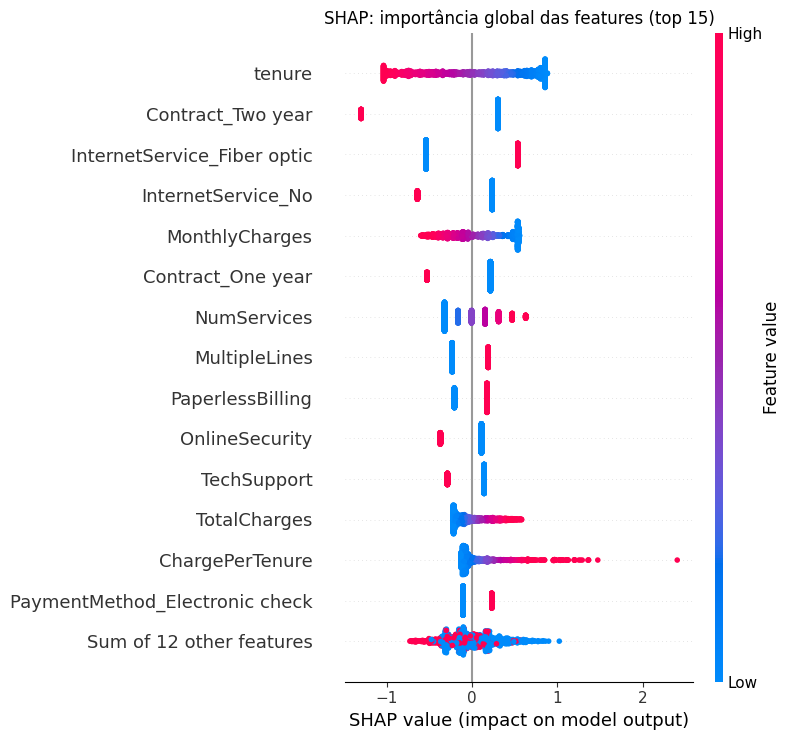

In [5]:
plt.figure()
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title('SHAP: importância global das features (top 15)')
plt.tight_layout()
plt.savefig('../data/figures/08_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Waterfall plot 
Explica a predição de um único cliente, aquele com a maior probabilidade de churn no conjunto de teste.  
Cada barra mostra quanto aquela feature empurrou a predição para cima (vermelho) ou para baixo (azul) em relação ao valor base esperado.

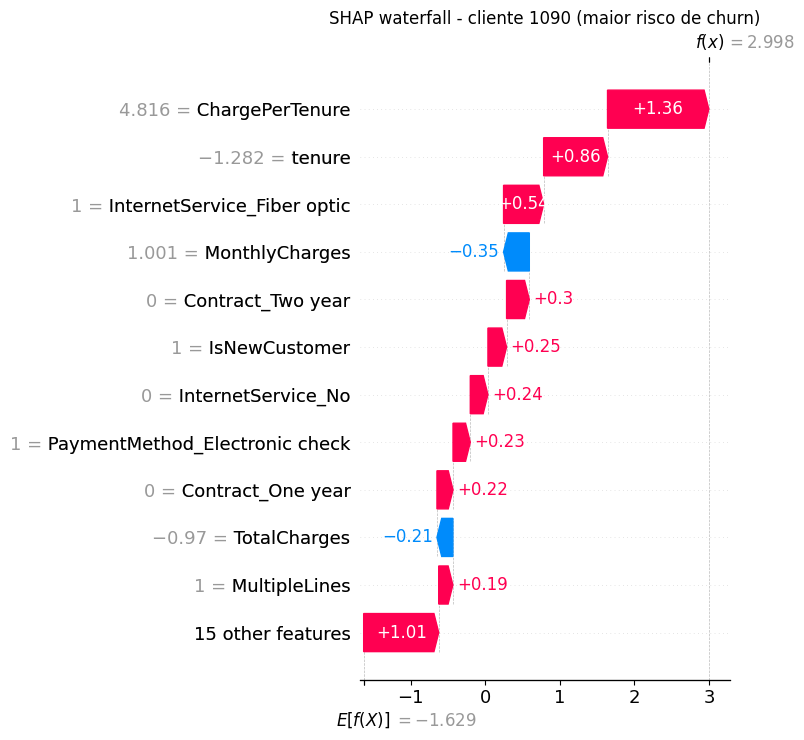

In [6]:
# Cliente com maior probabilidade de churn prevista
idx_max_churn = np.argmax(best_model.predict_proba(X_test_proc)[:, 1])

plt.figure()
shap.plots.waterfall(shap_exp[idx_max_churn], max_display=12, show=False)
plt.title(f'SHAP waterfall - cliente {idx_max_churn} (maior risco de churn)')
plt.tight_layout()
plt.savefig('../data/figures/09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Bar plot 
Versão agregada do beeswarm: média do valor absoluto de SHAP por feature em todo o conjunto de teste.  
Mais simples e direto e ideal para o README e para comunicar com stakeholders não técnicos.

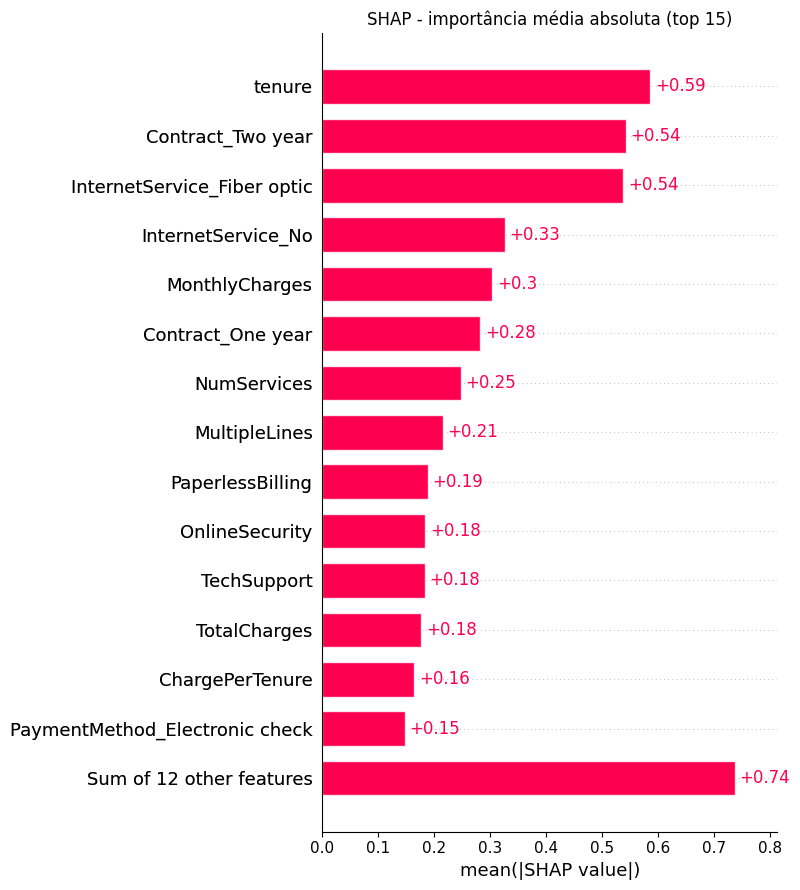

In [7]:
plt.figure()
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title('SHAP - importância média absoluta (top 15)')
plt.tight_layout()
plt.savefig('../data/figures/10_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hyperparameter Tuning com Optuna
O Optuna usa otimização Bayesiana (Tree-structured Parzen Estimator) para buscar hiperparâmetros de forma inteligente que é muito mais eficiente que GridSearch, que testa todas as combinações exaustivamente.  
A cada trial, o Optuna aprende quais regiões do espaço de busca são mais promissoras.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'C':            trial.suggest_float('C', 0.001, 10.0, log=True),
        'solver':       trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga']),
        'max_iter':     trial.suggest_int('max_iter', 200, 2000),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    # class_weight='balanced' é testado pois o dataset tem desbalanceamento 73/27
    model = LogisticRegression(**params, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train,
                            cv=cv, scoring='roc_auc').mean()
    return score

In [9]:
study = optuna.create_study(direction='maximize',
                             study_name='lr-churn-tuning')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMelhor AUC-ROC (CV): {study.best_value:.4f}")
print(f"Melhores parâmetros: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Melhor AUC-ROC (CV): 0.8489
Melhores parâmetros: {'C': 9.82552102792562, 'solver': 'saga', 'max_iter': 1786, 'class_weight': None}


### 3.1 Comparação baseline vs tunado
Avalia o modelo com os melhores parâmetros encontrados e compara com o baseline.

In [10]:
best_params = study.best_params
model_tuned = LogisticRegression(**best_params, random_state=42)
model_tuned.fit(X_train_proc, y_train)

y_proba_tuned = model_tuned.predict_proba(X_test_proc)[:, 1]
auc_tuned    = roc_auc_score(y_test, y_proba_tuned)
auc_baseline = roc_auc_score(y_test, best_model.predict_proba(X_test_proc)[:, 1])

print(f"AUC baseline: {auc_baseline:.4f}")
print(f"AUC tunado: {auc_tuned:.4f}")
print(f"Ganho:                {auc_tuned - auc_baseline:+.4f}")
# Ganho próximo de zero é esperado em Regressão Logística bem especificada:
# modelos lineares simples têm pouco espaço para melhoria via tuning

AUC baseline: 0.8468
AUC tunado: 0.8457
Ganho:                -0.0010


### 3.2 Histórico de otimização
Cada ponto azul é um trial. A linha verde mostra o melhor AUC acumulado ao longo da busca.  
A convergência rápida confirma que o espaço de busca foi bem explorado em 50 trials.

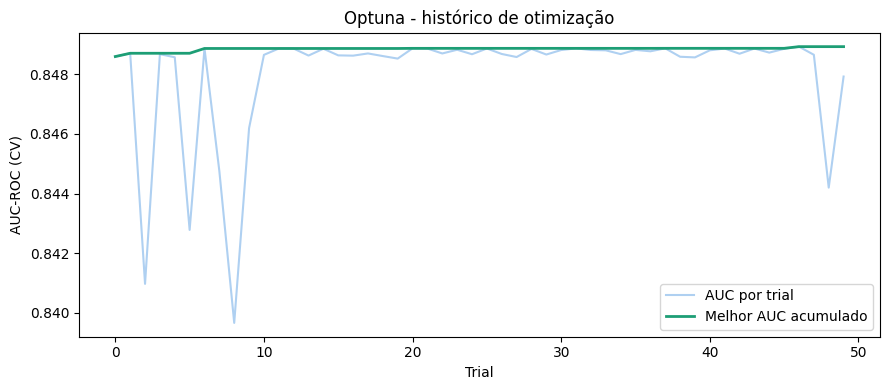

In [11]:
trial_values = [t.value for t in study.trials]

plt.figure(figsize=(9, 4))
plt.plot(trial_values, alpha=0.4, color='#378ADD', label='AUC por trial')
plt.plot(pd.Series(trial_values).cummax(), color='#1D9E75',
         linewidth=2, label='Melhor AUC acumulado')
plt.xlabel('Trial')
plt.ylabel('AUC-ROC (CV)')
plt.title('Optuna - histórico de otimização')
plt.legend()
plt.tight_layout()
plt.savefig('../data/figures/11_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Persistência: modelo tunado e log no MLflow

In [12]:
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('churn-prediction')

with mlflow.start_run(run_name='LogisticRegression_tuned'):
    mlflow.log_params(best_params)
    mlflow.log_metric('auc_roc_tuned',    round(auc_tuned, 4))
    mlflow.log_metric('auc_roc_baseline', round(auc_baseline, 4))
    mlflow.sklearn.log_model(model_tuned, 'LogisticRegression_tuned')

# Salvar modelo tunado para uso no Streamlit
joblib.dump(model_tuned, '../models/best_model_tuned.pkl')
print("Modelo tunado salvo.")

Modelo tunado salvo.


## 5. Insights: SHAP e Optuna

### Explicabilidade (SHAP)
- Features mais impactantes (beeswarm): `Contract_Two year`, `tenure` e `Contract_One year` têm os maiores SHAP negativos, clientes com contratos longos e maior tempo de casa têm risco reduzido de churn
- `PaymentMethod_Electronic check` aparece com SHAP positivo consistente, o pagamento por boleto eletrônico está associado a maior risco
- `NumServices` e `OnlineSecurity` com SHAP negativo: quanto mais serviços contratados e com suporte ativo, menor o churn, engajamento protege a retenção
- `IsNewCustomer` com SHAP positivo: clientes nos primeiros 6 meses têm risco elevado, hipótese do EDA confirmada pelo modelo

### Tuning (Optuna)
- Melhores parâmetros: C= 9.82, solver=saga, max_iter=1786, class_weight=None
- Ganho de AUC com tuning  ≈ -0.0010 (praticamente nulo)
- Resultado esperado: Regressão Logística com features bem engenheiradas já estava próxima do ótimo com parâmetros padrão mesmo que 
modelos lineares simples possuem pouco espaço para melhoria via tuning
- O modelo baseline do é mantido como modelo final por ser equivalente e mais simples